In [2]:
from __future__ import annotations

import math
import random
from collections import Counter, defaultdict
from statistics import mean, median
import matplotlib.pyplot as plt
import numpy as np

try:
    import pandas as pd
except Exception:
    pd = None

USERS_CSV = 'clean_users_from_raw.csv'
EVENTS_CSV = 'clean_events_from_raw.csv'  # optional

BOOTSTRAP_ITERS = 20000
BOOTSTRAP_SEED = 7

### Step 1 — Load data

We load the user-level table (required). If the event-level table exists, we also load it to enable:

- users ↔ events consistency checks
- per-task drill-down

In [3]:
import os

if pd is None:
    raise RuntimeError("This notebook expects pandas. Please install it: pip install pandas")

users_df = pd.read_csv(USERS_CSV)
print("Loaded users:", users_df.shape)
display(users_df.head())

events_df = None
if os.path.exists(EVENTS_CSV):
    events_df = pd.read_csv(EVENTS_CSV)
    print("Loaded events:", events_df.shape)
    display(events_df.head())
else:
    print("Events file not found, skipping event-level checks/drill-down:", EVENTS_CSV)

Loaded users: (74, 7)


,user_id,app_version,tasks_completed_at_dropout,rating,total_time_spent_seconds,avg_time_spent_seconds,tasks_completed_list
0,07736719-4a6f-4d13-b43b-7a27c1aed2c9,A,3,4,45.15,15.05,Task 1|Task 2|Task 3
1,0cc8e3c1-fe7e-4f3a-920c-cf7cfed7c65f,B,9,3,1362.10,151.34,Task 1|Task 2|Task 3|Task 4|Task 5|Task 6|Task...
2,0d28e9a6-3fce-46c0-a5cd-a8b76bf1d331,A,9,3,224.05,24.89,Task 1|Task 2|Task 3|Task 4|Task 5|Task 6|Task...
3,0f1be914-7fb3-48b0-99de-40113d800b6d,B,11,5,1108.81,100.80,Task 1|Task 2|Task 3|Task 4|Task 5|Task 6|Task...
4,10037e18-7099-4d6c-a325-e5f58d7e25b8,B,6,2,285.77,47.63,Task 1|Task 2|Task 3|Task 4|Task 5|Task 6


Loaded events: (421, 8)


,app_version,task_id,user_id,date,date_hour,time_spent_seconds,tasks_completed_at_dropout,rating
0,A,Task 1,07736719-4a6f-4d13-b43b-7a27c1aed2c9,20260411.0,2.026041e+09,11.98,3,4
1,A,Task 3,07736719-4a6f-4d13-b43b-7a27c1aed2c9,20260411.0,2.026041e+09,13.20,3,4
2,A,Task 2,07736719-4a6f-4d13-b43b-7a27c1aed2c9,20260411.0,2.026041e+09,19.97,3,4
3,B,Task 5,0cc8e3c1-fe7e-4f3a-920c-cf7cfed7c65f,20260412.0,2.026041e+09,5.01,9,3
4,B,Task 2,0cc8e3c1-fe7e-4f3a-920c-cf7cfed7c65f,20260412.0,2.026041e+09,85.63,9,3


### Step 2 — Basic sanity checks

We verify:
- group sizes and split (A vs B)
- ratings are within 1..5
- time columns are non-negative
- (if events provided) users ↔ events consistency: version, rating, dropout, and aggregated time

In [4]:
required_user_cols = {
    "user_id",
    "app_version",
    "tasks_completed_at_dropout",
    "rating",
    "total_time_spent_seconds",
    "avg_time_spent_seconds",
}
missing = required_user_cols - set(users_df.columns)
if missing:
    raise ValueError(f"users_df missing columns: {missing}")

print("Group split:")
display(users_df["app_version"].value_counts())

bad_rating = users_df[~users_df["rating"].between(1, 5)]
print("Bad ratings:", len(bad_rating))
if len(bad_rating):
    display(bad_rating.head())

for col in ["total_time_spent_seconds", "avg_time_spent_seconds"]:
    bad = users_df[users_df[col] < 0]
    print(f"Negative {col}:", len(bad))

if events_df is not None:
    required_event_cols = {
        "app_version",
        "task_id",
        "user_id",
        "date",
        "date_hour",
        "time_spent_seconds",
        "tasks_completed_at_dropout",
        "rating",
    }
    missing_e = required_event_cols - set(events_df.columns)
    if missing_e:
        raise ValueError(f"events_df missing columns: {missing_e}")

    # Check user_id sets match
    user_set_users = set(users_df["user_id"])
    user_set_events = set(events_df["user_id"])
    print("user_id set match:", user_set_users == user_set_events)
    print("missing in events:", len(user_set_users - user_set_events))
    print("missing in users:", len(user_set_events - user_set_users))

    # Check per-user consistency for version/rating/dropout and aggregated times
    ev_g = events_df.groupby("user_id")
    per_user = ev_g.agg(
        app_version_nunique=("app_version", "nunique"),
        rating_nunique=("rating", "nunique"),
        dropout_nunique=("tasks_completed_at_dropout", "nunique"),
        event_rows=("task_id", "count"),
        dropout_first=("tasks_completed_at_dropout", "first"),
        rating_first=("rating", "first"),
        app_version_first=("app_version", "first"),
        total_time_events=("time_spent_seconds", "sum"),
        avg_time_events=("time_spent_seconds", "mean"),
    ).reset_index()

    merged = users_df.merge(per_user, on="user_id", how="left")

    problems = []
    problems.append(("multi_version", merged[merged["app_version_nunique"] != 1]))
    problems.append(("multi_rating", merged[merged["rating_nunique"] != 1]))
    problems.append(("multi_dropout", merged[merged["dropout_nunique"] != 1]))
    problems.append(("dropout_mismatch_event_rows", merged[merged["dropout_first"] != merged["event_rows"]]))
    problems.append(("dropout_mismatch_users", merged[merged["tasks_completed_at_dropout"] != merged["dropout_first"]]))
    problems.append(("rating_mismatch_users", merged[merged["rating"] != merged["rating_first"]]))
    problems.append(("version_mismatch_users", merged[merged["app_version"] != merged["app_version_first"]]))
    problems.append(("total_time_mismatch", merged[(merged["total_time_spent_seconds"] - merged["total_time_events"]).abs() > 0.05]))
    problems.append(("avg_time_mismatch", merged[(merged["avg_time_spent_seconds"] - merged["avg_time_events"]).abs() > 0.05]))

    print("\nConsistency checks (should all be 0):")
    for name, dfp in problems:
        print(f"- {name}: {len(dfp)}")

    # Show first issue if any
    for name, dfp in problems:
        if len(dfp):
            print("\nExample inconsistency:", name)
            display(dfp.head(3))
            break

Group split:


app_version
A    38
B    36
Name: count, dtype: int64

Bad ratings: 0
Negative total_time_spent_seconds: 0
Negative avg_time_spent_seconds: 0
user_id set match: True
missing in events: 0
missing in users: 0

Consistency checks (should all be 0):
- multi_version: 0
- multi_rating: 0
- multi_dropout: 0
- dropout_mismatch_event_rows: 0
- dropout_mismatch_users: 0
- rating_mismatch_users: 0
- version_mismatch_users: 0
- total_time_mismatch: 0
- avg_time_mismatch: 0


### Step 3 — Define statistical helpers

We compute:
- Welch’s t-test (two-sided p-value, normal approximation)
- bootstrap 95% CI for mean difference (A − B)
- Cohen’s d effect size

In [5]:
def welch_t(a, b):
    a = list(a)
    b = list(b)
    na, nb = len(a), len(b)
    ma, mb = mean(a), mean(b)
    va = sum((x - ma) ** 2 for x in a) / (na - 1)
    vb = sum((x - mb) ** 2 for x in b) / (nb - 1)
    se = math.sqrt(va / na + vb / nb)
    t = (ma - mb) / se if se > 0 else 0.0

    df_num = (va / na + vb / nb) ** 2
    df_den = (va * va) / (na * na * (na - 1)) + (vb * vb) / (nb * nb * (nb - 1))
    df = df_num / df_den if df_den > 0 else (na + nb - 2)
    return float(t), float(df)


def p_two_sided_normal_approx(t):
    z = abs(t)
    return 2.0 * (1.0 - 0.5 * (1.0 + math.erf(z / math.sqrt(2.0))))


def bootstrap_ci_diff_mean(a, b, iters=BOOTSTRAP_ITERS, seed=BOOTSTRAP_SEED):
    a = list(a)
    b = list(b)
    rng = random.Random(seed)
    na, nb = len(a), len(b)
    diffs = []
    for _ in range(iters):
        sa = [a[rng.randrange(na)] for _ in range(na)]
        sb = [b[rng.randrange(nb)] for _ in range(nb)]
        diffs.append(mean(sa) - mean(sb))
    diffs.sort()
    lo = diffs[int(0.025 * iters)]
    hi = diffs[int(0.975 * iters)]
    return float(lo), float(hi)


def cohens_d(a, b):
    a = list(a)
    b = list(b)
    na, nb = len(a), len(b)
    ma, mb = mean(a), mean(b)
    va = sum((x - ma) ** 2 for x in a) / (na - 1)
    vb = sum((x - mb) ** 2 for x in b) / (nb - 1)
    sp = math.sqrt(((na - 1) * va + (nb - 1) * vb) / (na + nb - 2))
    return float((ma - mb) / sp) if sp > 0 else 0.0

### Step 4 — User-level AB test (primary)

We test the main hypothesis:
- **Efficiency**: A has lower `total_time_spent_seconds`
- **Usability**: A has higher `rating`

We also report supportive/context metrics.

In [6]:
A = users_df[users_df["app_version"] == "A"].copy()
B = users_df[users_df["app_version"] == "B"].copy()

def metric_report(col_name: str, better: str):
    a = A[col_name].astype(float).tolist()
    b = B[col_name].astype(float).tolist()

    t, df = welch_t(a, b)
    p = p_two_sided_normal_approx(t)
    ci_lo, ci_hi = bootstrap_ci_diff_mean(a, b)
    d = cohens_d(a, b)

    return {
        "metric": col_name,
        "better": better,
        "A_n": len(a),
        "A_mean": mean(a),
        "A_median": median(a),
        "B_n": len(b),
        "B_mean": mean(b),
        "B_median": median(b),
        "diff_mean_A_minus_B": mean(a) - mean(b),
        "bootstrap95ci_lo": ci_lo,
        "bootstrap95ci_hi": ci_hi,
        "welch_t": t,
        "df": df,
        "p_two_sided_approx": p,
        "cohens_d": d,
    }

reports = []
reports.append(metric_report("total_time_spent_seconds", better="lower"))
reports.append(metric_report("rating", better="higher"))
reports.append(metric_report("avg_time_spent_seconds", better="lower"))
reports.append(metric_report("tasks_completed_at_dropout", better="context"))

report_df = pd.DataFrame(reports)

# Make the table easier to read
cols_order = [
    "metric",
    "better",
    "A_n",
    "A_mean",
    "B_n",
    "B_mean",
    "diff_mean_A_minus_B",
    "bootstrap95ci_lo",
    "bootstrap95ci_hi",
    "p_two_sided_approx",
    "cohens_d",
]
report_df = report_df[cols_order]

# Pretty formatting
for c in ["A_mean", "B_mean", "diff_mean_A_minus_B", "bootstrap95ci_lo", "bootstrap95ci_hi", "cohens_d"]:
    report_df[c] = report_df[c].map(lambda x: float(f"{x:.4f}"))
report_df["p_two_sided_approx"] = report_df["p_two_sided_approx"].map(lambda x: float(f"{x:.6f}"))

display(report_df)

# Quick, human-readable conclusions
primary_time = report_df[report_df["metric"] == "total_time_spent_seconds"].iloc[0]
primary_rating = report_df[report_df["metric"] == "rating"].iloc[0]

print("\n=== Decision helper (typical alpha=0.05) ===")
print("Efficiency (total_time):")
print("  A_mean < B_mean ?", primary_time["A_mean"] < primary_time["B_mean"], "| p=", primary_time["p_two_sided_approx"])
print("Usability (rating):")
print("  A_mean > B_mean ?", primary_rating["A_mean"] > primary_rating["B_mean"], "| p=", primary_rating["p_two_sided_approx"])

,metric,better,A_n,A_mean,B_n,B_mean,diff_mean_A_minus_B,bootstrap95ci_lo,bootstrap95ci_hi,p_two_sided_approx,cohens_d
0,total_time_spent_seconds,lower,38,315.5155,36,611.9572,-296.4417,-525.7974,-90.5542,0.008365,-0.6239
1,rating,higher,38,4.1842,36,2.6389,1.5453,1.0804,2.0073,0.000000,1.5039
2,avg_time_spent_seconds,lower,38,63.6239,36,86.6808,-23.0569,-52.9219,9.6470,0.153920,-0.3296
3,tasks_completed_at_dropout,context,38,5.1053,36,6.3056,-1.2003,-2.7515,0.3406,0.131622,-0.3503



=== Decision helper (typical alpha=0.05) ===
Efficiency (total_time):
  A_mean < B_mean ? True | p= 0.008365
Usability (rating):
  A_mean > B_mean ? True | p= 0.0


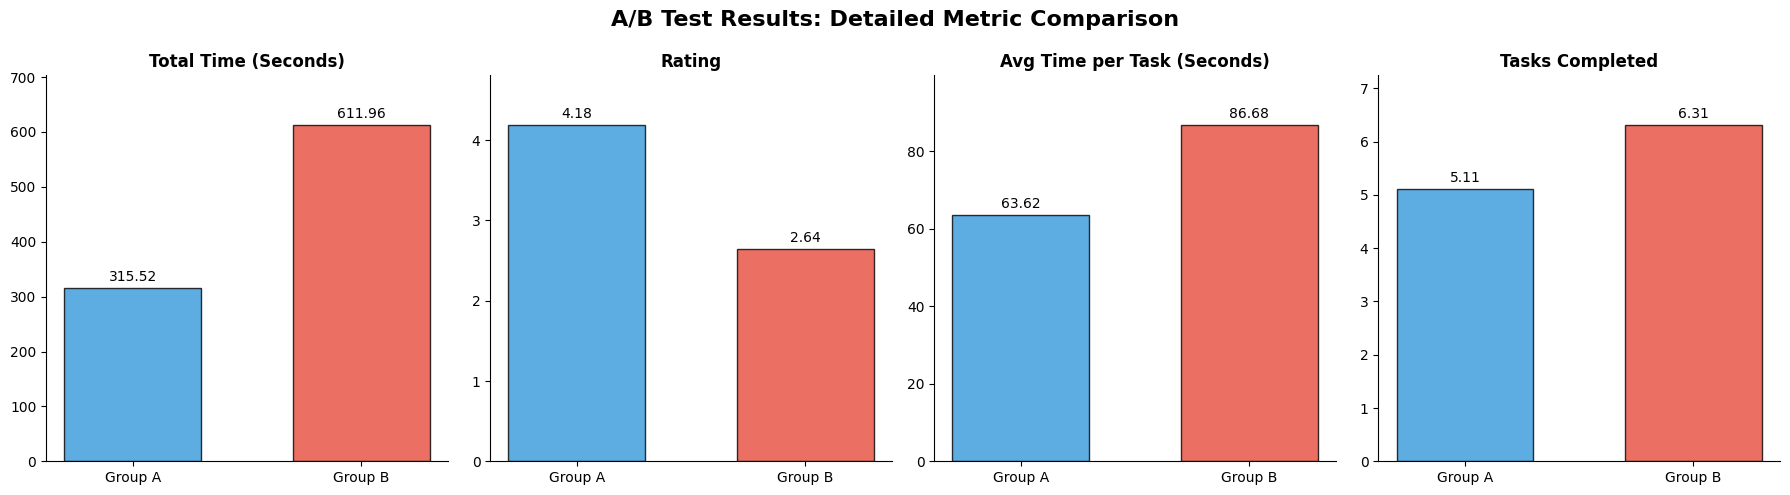

In [11]:
groups = ('Group A', 'Group B')
metrics = {
    'Total Time (Seconds)': tuple(report_df[['A_mean', 'B_mean']].values[0]),
    'Rating': tuple(report_df[['A_mean', 'B_mean']].values[1]),
    'Avg Time per Task (Seconds)': tuple(report_df[['A_mean', 'B_mean']].values[2]),
    'Tasks Completed': tuple(report_df[['A_mean', 'B_mean']].values[3])
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('A/B Test Results: Detailed Metric Comparison', fontsize=16, fontweight='bold')

colors = ['#3498db', '#e74c3c']

for i, (name, values) in enumerate(metrics.items()):
    ax = axes[i]
    bars = ax.bar(groups, values, color=colors, width=0.6, edgecolor='black', alpha=0.8)
    
    ax.set_title(name, fontsize=12, fontweight='bold')
    
    ax.bar_label(bars, padding=3, fmt='%.2f', fontsize=10)
    ax.set_ylim(0, max(values) * 1.15)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

### Step 5 — Event-level per-task drill-down (optional)

This is *exploratory* (multiple comparisons). It helps you explain which tasks drive the overall time difference.

If `clean_events_from_raw.csv` was not provided, you can skip this section.

In [8]:
if events_df is None:
    print("No events_df loaded. Skip per-task drill-down.")
else:
    # Keep valid task rows only
    ev = events_df[events_df["task_id"].astype(str).str.match(r"^Task\s+(1[01]|[1-9])$")].copy()
    ev["task_num"] = ev["task_id"].str.split().str[1].astype(int)

    rows = []
    for task_id, g in ev.groupby("task_id"):
        a = g[g["app_version"] == "A"]["time_spent_seconds"].astype(float).tolist()
        b = g[g["app_version"] == "B"]["time_spent_seconds"].astype(float).tolist()
        if len(a) < 1 or len(b) < 1:
            continue
        t, df = welch_t(a, b)
        p = p_two_sided_normal_approx(t)
        rows.append(
            {
                "task_id": task_id,
                "nA": len(a),
                "meanA": mean(a),
                "nB": len(b),
                "meanB": mean(b),
                "diff_mean_A_minus_B": mean(a) - mean(b),
                "p_two_sided_approx": p,
            }
        )

    task_df = pd.DataFrame(rows)
    if len(task_df) == 0:
        print("Not enough per-task data to report.")
    else:
        task_df["task_num"] = task_df["task_id"].str.split().str[1].astype(int)
        task_df = task_df.sort_values("task_num").drop(columns=["task_num"]) \
            .reset_index(drop=True)

        for c in ["meanA", "meanB", "diff_mean_A_minus_B"]:
            task_df[c] = task_df[c].map(lambda x: float(f"{x:.2f}"))
        task_df["p_two_sided_approx"] = task_df["p_two_sided_approx"].map(lambda x: float(f"{x:.6f}"))

        display(task_df)

,task_id,nA,meanA,nB,meanB,diff_mean_A_minus_B,p_two_sided_approx
0,Task 1,38,74.94,36,65.00,9.94,0.619489
1,Task 2,28,80.32,30,180.74,-100.42,0.068032
2,Task 3,26,15.86,30,21.84,-5.98,0.005538
3,Task 4,22,98.50,27,142.44,-43.94,0.071284
4,Task 5,21,78.32,26,119.01,-40.69,0.384944
5,Task 6,16,79.79,22,191.55,-111.76,0.105187
6,Task 7,15,13.90,18,40.63,-26.73,0.000037
7,Task 8,13,50.99,15,19.63,31.36,0.097264
8,Task 9,7,20.75,10,51.57,-30.81,0.013484
9,Task 10,4,17.30,8,39.78,-22.49,0.007633


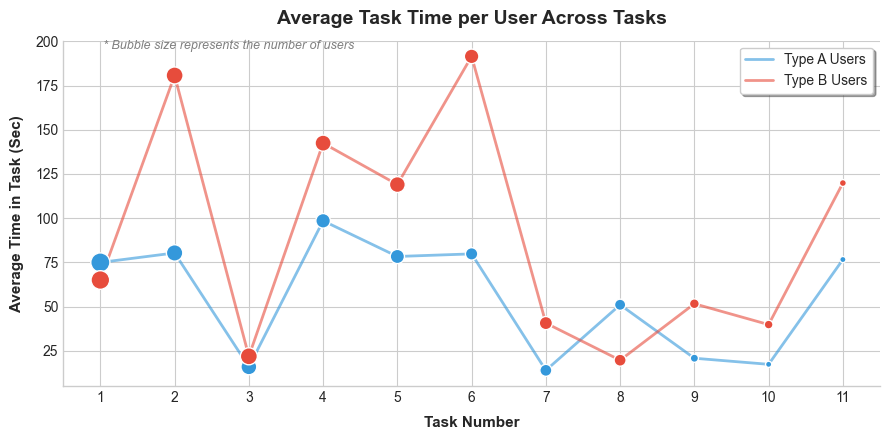

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9, 4.5)) 

color_A = '#3498db'
color_B = '#e74c3c'

ax.plot(task_df['task_num'], task_df['meanA'], color=color_A, linewidth=2, alpha=0.6, label='Type A Users')
ax.plot(task_df['task_num'], task_df['meanB'], color=color_B, linewidth=2, alpha=0.6, label='Type B Users')

scale_factor = 5 

ax.scatter(task_df['task_num'], task_df['meanA'], s=task_df['nA'] * scale_factor, 
           color=color_A, edgecolor='white', linewidth=1, zorder=5)
ax.scatter(task_df['task_num'], task_df['meanB'], s=task_df['nB'] * scale_factor, 
           color=color_B, edgecolor='white', linewidth=1, zorder=5)

ax.set_xlabel("Task Number", fontsize=11, fontweight='bold', labelpad=8)
ax.set_ylabel("Average Time in Task (Sec)", fontsize=11, fontweight='bold', labelpad=8)
ax.set_title("Average Task Time per User Across Tasks", fontsize=14, fontweight='bold', pad=12)

ax.set_xticks(task_df['task_num'])

ax.legend(loc='upper right', fontsize=10, frameon=True, shadow=True)

fig.text(0.12, 0.88, '* Bubble size represents the number of users', fontsize=9, style='italic', color='gray')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()